# Iqram Haris Fahromi
## ID 975120354

##### *I would like to clarify that I picked the S-wave on the vertical (Z) component only for this assignment, as an example. I understand that S-wave picking should be done on the horizontal components (N/E), thank you Mr. Kasper.

# e316: Seismic Ray Tracing

In this lab, we will explore how seismic ray tracing can be used to model the propagation of seismic energy through the earth. Using ray tracing, we will estimate the epicentral distance and origin time for an earthquake.

Chapter 11 of [A Guided Tour of Mathematical Methods for the Physical Sciences](http://www.cambridge.org/nz/academic/subjects/physics/mathematical-methods/guided-tour-mathematical-methods-physical-sciences-3rd-edition#W7jZxE54KWWuUWEC.97), *Scale Analysis*, discusses the conditions where waves can be considered in terms of ray theory. This is not a bad approximation when the spatial variability in the physical parameters that define the wave propagation is large compared to the propagating wavelengths. In that case, the wave equation, can be reduced to the Eikonal equation, which describes the travel time $T$ of a seismic ray in a medium with wave speed $v({\bf r})$ as $$ |\nabla T({\bf r})|^2 = 1/v({\bf r})^2.$$ In our book you can read how to derive [Snell's Law](https://en.wikipedia.org/wiki/Snell%27s_law) from the Eikonal equation, for example. 

There are many strategies under the umbrella of "ray tracing" to find the travel time of rays in media with arbitrary velocity distributions, but here we will explore the travel time and ray path of seismic waves in a spherically symmetric approximation of Earth.

### **Rays in a spherically symmetric Earth**
Having accepted ray theory in the Earth for high-frequency seismic waves, we can estimate the travel time $T$ and epicentral distance $\Delta$ of "seismic rays." To first order, the Earth is spherically symmetric, greatly simplifying ray propagation. In a spherically symmetric Earth, the 3D velocity distribution reduces to a 1D model: $v({\bf r})= v(r)$: 
![Figure 1](https://auckland.figshare.com/ndownloader/files/14738099)

First, a small part of the ray path $ds$ satisfies Pythagoras' Rule: $ds^2 = dr^2 + (rd\Delta)^2$. Second, the take-off angle $i$ is the angle of the ray with the normal to the Earth's surface. A triangle shows that $\sin(i) = rd\Delta/ds$  Thirdly, Snell's Law in a spherically symmetric Earth is $r\sin (i) /v(r)=p$. This constant $p$ is called the ray parameter. 

#### **Question 1**
Combining these three expressions, show that

$$ \frac{ds}{dr} = \frac{r}{\sqrt{r^2-(pv)^2}} \ \ \ \ \ \mbox{and}   \ \ \ \ \ \ \frac{d\Delta}{dr} = \frac{pv/r}{\sqrt{r^2-(pv)^2}}.$$
### **Time and distance of a ray**
To find the total ray path length $s$ and the epicentral distance $\Delta$ traveled by the ray, we integrate these expressions with regards to $r$.

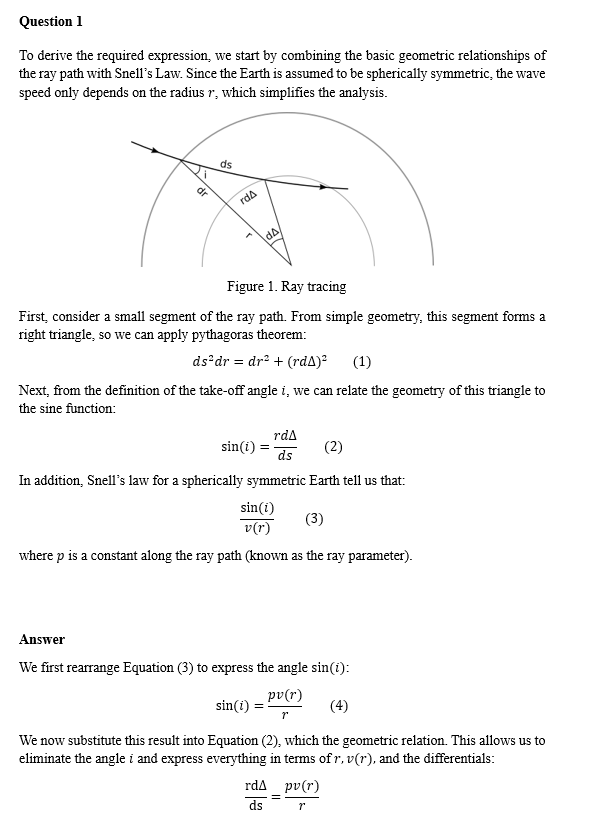
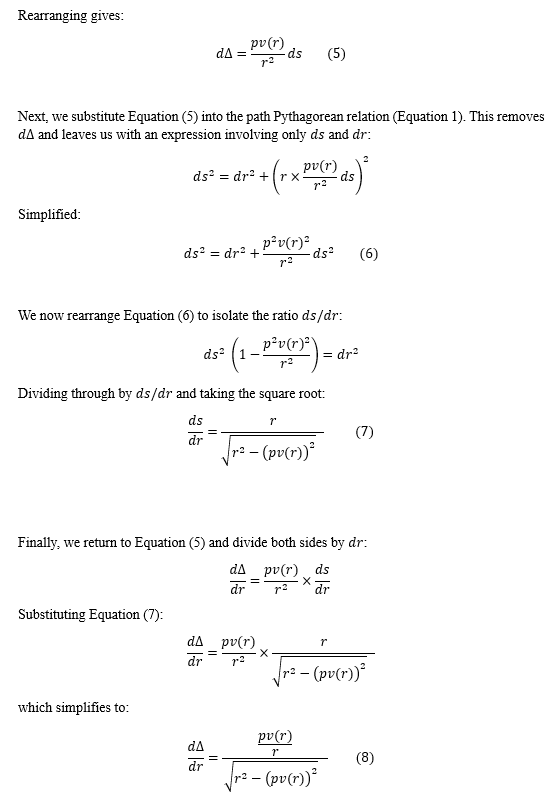
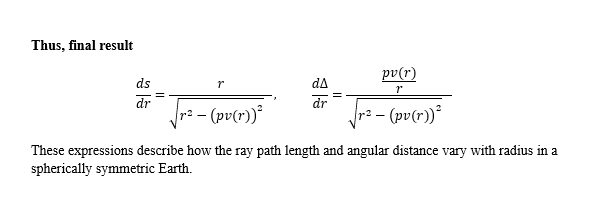

Let's consider a ray that starts and ends at the surface, and travels an epicentral distance $\Delta$:

![Figure 2](https://auckland.figshare.com/ndownloader/files/14754827)

Then, we take advantage of the symmetry, by integrating twice from the point of maximum depth of the ray $r=r_0$ to the surface $r= R$:
$$
\Delta(p) = 2 \int_{r_0}^R \frac{pv/r} {\sqrt{r^2-(pv)^2}}dr.
$$ 

The travel time requires integration of $\frac{1}{v}\frac{ds}{dr}$ over $r$, so that:
$$
T(p) = 2 \int_{r_0}^R \frac{r/v} {\sqrt{r^2-(pv)^2}}dr.
$$
These equations could have also been derived directly from the Eikonal equation and the equation of kinematic ray tracing (see Aki and Richards, for example).

### **Rays in a sphere with constant speed**
In his book *Principles of Seismology*, Udias derives expressions for travel time and epicentral distance from source to receiver for the special case of a sphere with radius $R$ and a constant speed: $v(r) =c$. In this simplest of cases, the rays don't bend: 
![Figure 3](https://auckland.figshare.com/ndownloader/files/14777435)

The travel time for these rays with ray parameter $p$ is 
$$
T(p) = \frac{2}{c}\sqrt{R^2-p^2c^2},
$$
and the epicentral distance is
$$
\Delta(p) = 2\cos^{-1}\left(\frac{pc}{R}\right).
$$

####  **Question 2**
If you are a real buff in solving integrals analytically, you can set $v(r) = c$ and solve the integrals for $T$ and $\Delta$ from earlier in this notebook, but they are not easy! Instead, convince yourself of Udias' results by differentiating the expressions for $T$ and $\Delta$ with respect to $R=r$ to confirm the integrands for the general expressions of $T(p)$ and $\Delta(p)$ stated earlier.

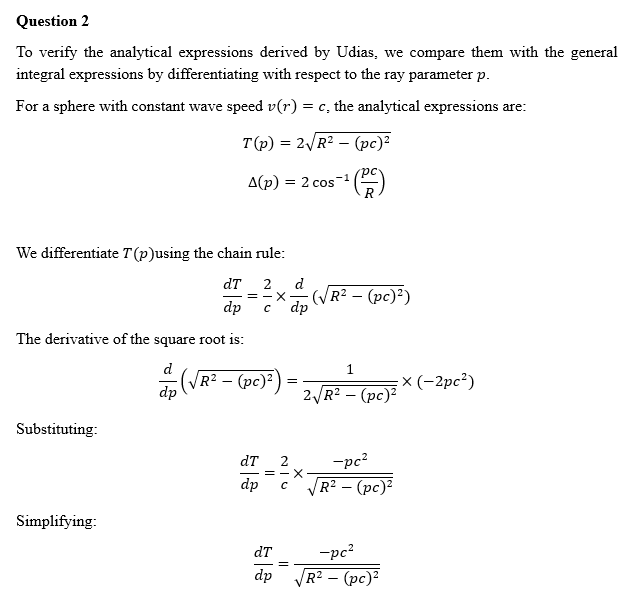
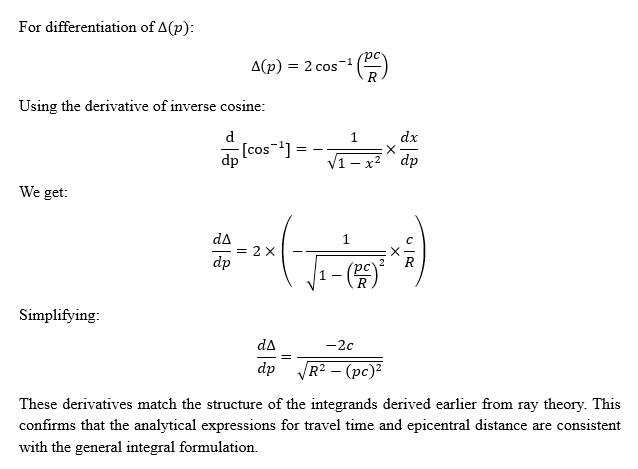

### Comparing analytic with numerical solutions

We can now compare the analytic solution and the integral solution with a numerical approximation.
The code cell below calculates and plots the analytic and numerical expression for the travel time as a function of take-off angle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import cartopy.crs as ccrs
from scipy.integrate import quad
from scipy.interpolate import interp1d
from obspy.taup import TauPyModel
from obspy.core import UTCDateTime
from obspy.taup import plot_travel_times
from obspy.clients.fdsn import Client
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

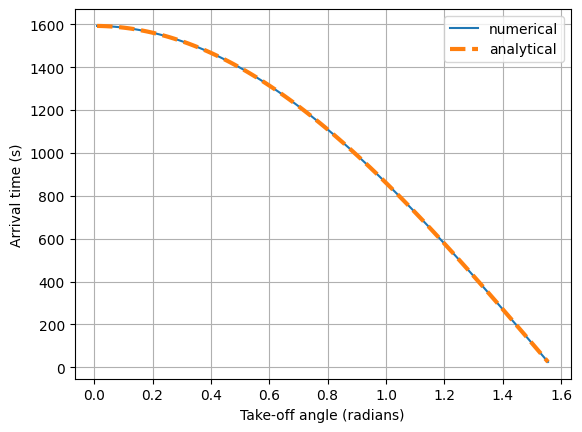

In [2]:
#Q1 #example
#%matplotlib notebook # comment this line out if you are using Colab, because it would not work.

# Set the wavespeed and radius of the sphere:
c = 8 # in km/s
R = 6371 # radius in km

# Function defining the integrand for travel time:
def T_integrand(r, c, p):
    return (2*r/c)/np.sqrt(r**2-(c*p)**2)

# We define a range of incidence angles/slash ray parameters:
angles = np.linspace(0.01,0.99*np.pi/2,100) # (almost) all angles, just avoiding some singularities
ps = R*np.sin(angles)/c

# the analytic travel times are:
Ts_udias =  2*np.sqrt(R**2 - ps**2*c**2)/c

# Compute a travel time t for each value of p:
Ts= [] # set up a list for the travel times for each p
for p in ps:
    T= quad(T_integrand, p*c, R, args = (c,p))[0]
    Ts.append(T)

plt.figure()
plt.plot(angles,Ts,label = 'numerical')
plt.plot(angles,Ts_udias,linewidth = 3, linestyle = '--',label = 'analytical')
plt.legend()
plt.xlabel('Take-off angle (radians)')
plt.ylabel('Arrival time (s)')
plt.grid()
plt.show()

#### **Question 3**
Calculate and plot the analytic and numerical solutions for the *epicentral distance* $\Delta$ traveled by a ray as a function of its take-off angle.

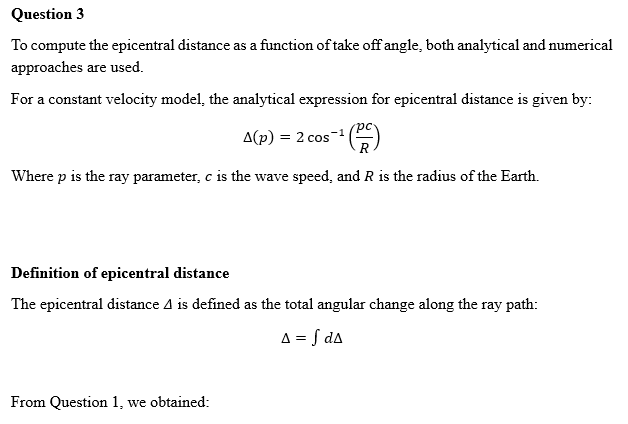
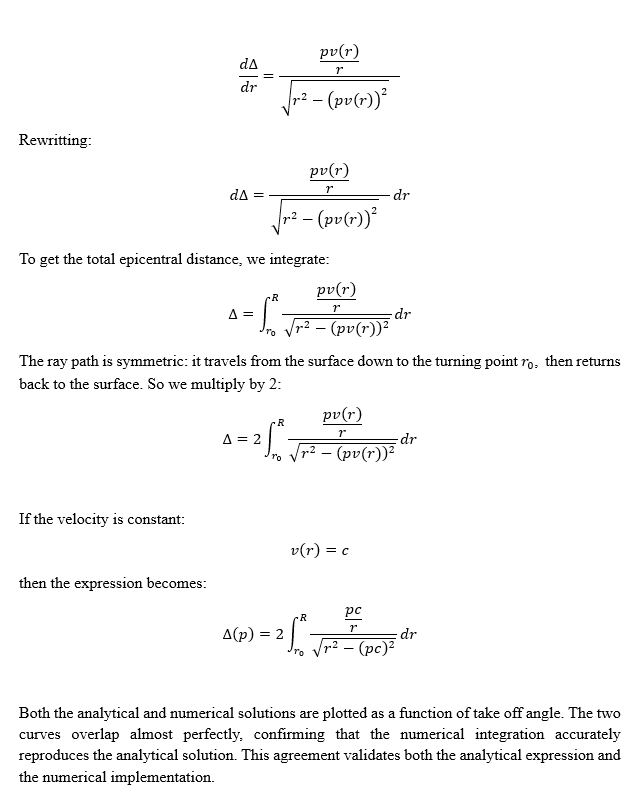

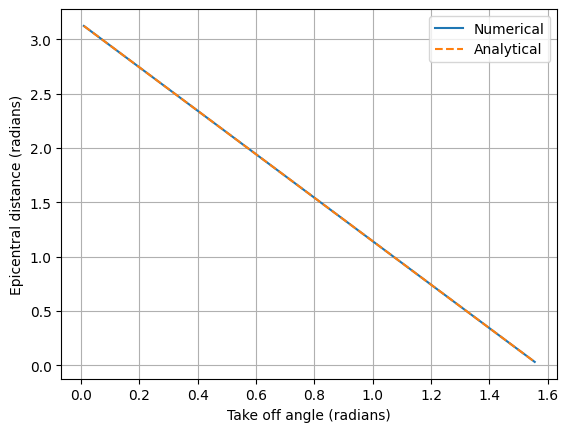

In [3]:
# Q3
# Constants
c = 8        # velocity (km/s)
R = 6371     # Earth radius (km)

# Integrand for Delta
def Delta_integrand(r, c, p):
    return (2 * p * c / r) / np.sqrt(r**2 - (c*p)**2)

# Take off angles
angles_q3 = np.linspace(0.01, 0.99*np.pi/2, 100)

# Ray parameters
ps_q3 = R * np.sin(angles_q3) / c

# Analytical solution
Delta_analytic = 2 * (np.arccos(ps_q3 * c / R))

# Numerical solution
Delta_numeric = []

for p in ps_q3:
    Delta = quad(Delta_integrand, p*c, R, args = (c,p))[0]
    Delta_numeric.append(Delta)


plt.figure()
plt.plot(angles_q3, Delta_numeric, label = 'Numerical')
plt.plot(angles_q3, Delta_analytic, '--', label = 'Analytical')
plt.xlabel('Take off angle (radians)')
plt.ylabel('Epicentral distance (radians)')
plt.legend()
plt.grid()
plt.show()
#Delta_analytic

### The travel time of a specific ray
Now that you have travel time $T$ and epicentral distance $\Delta$ as a function of take of angle, you can determine the travel time of a ray that travels a certain epicentral distance!

#### Question 4
Plot travel time as a function of epicentral distance. 

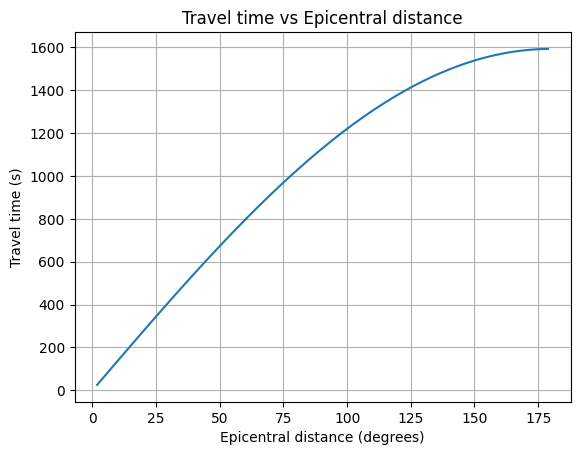

In [4]:
# Q4
# Constants
c = 8        # km/s
R = 6371     # km

# Integrand for travel time
def T_integrand(r, c, p):
    return (2*r/c)/np.sqrt(r**2 - (c*p)**2)

# Integrand for epicentral distance
def Delta_integrand(r, c, p):
    return (2*p*c/r)/np.sqrt(r**2 - (c*p)**2)

# Angles
angles = np.linspace(0.01, 0.99*np.pi/2, 100)

# Ray parameter
ps = R * np.sin(angles) / c

T_vals = []
Delta_vals = []

for p in ps:
    T = quad(T_integrand, p*c, R, args = (c,p))[0]
    Delta = quad(Delta_integrand, p*c, R, args = (c,p))[0]
    
    T_vals.append(T)
    Delta_vals.append(Delta)

# Convert Delta to degrees
Delta_deg = np.array(Delta_vals) * 180/np.pi

plt.figure()
plt.plot(Delta_deg, T_vals)
plt.xlabel('Epicentral distance (degrees)')
plt.ylabel('Travel time (s)')
plt.title('Travel time vs Epicentral distance')
plt.grid()
plt.show()

Why is the relation between travel time and epicentral distance not linear? The velocity is constant, after all....
A hint: plot travel time $T$ as a function of ray length $s$. To determine $s$, consider the triangle
and the sine rule that states $$\frac{s}{\sin(\Delta)} = \frac{R}{\sin\left(i\right)} = \frac{R}{\sin\left(\frac{\pi-\Delta}{2}\right)}.$$

![Figure 4](https://auckland.figshare.com/ndownloader/files/14777429)

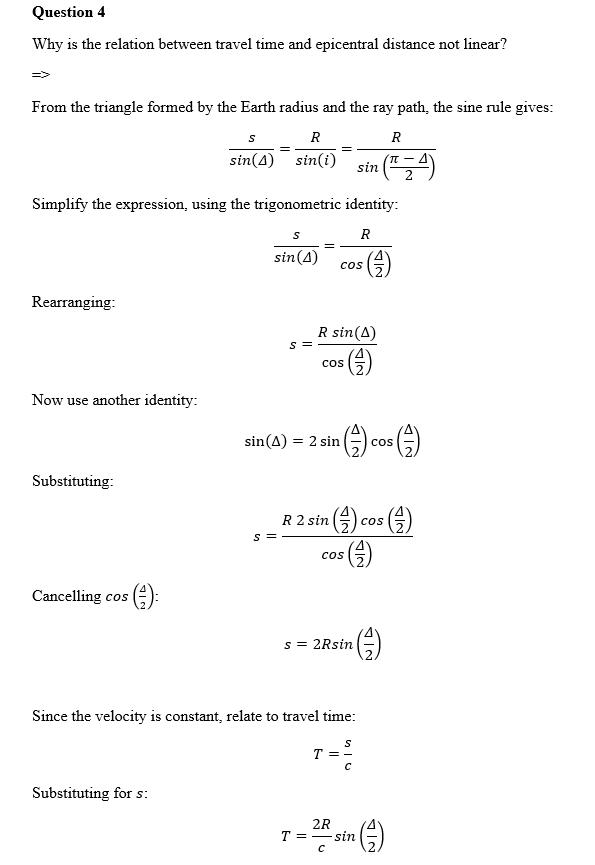
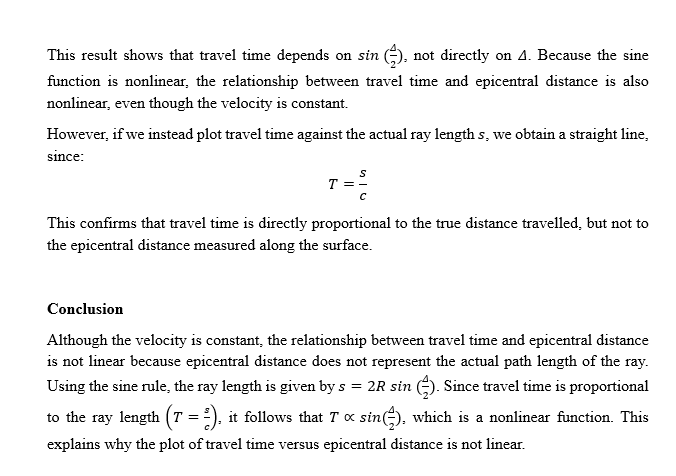

#### Question 5

Plot $s$ versus $T$ and explain what you see here. Why is it a straight line? What is the slope of this line?

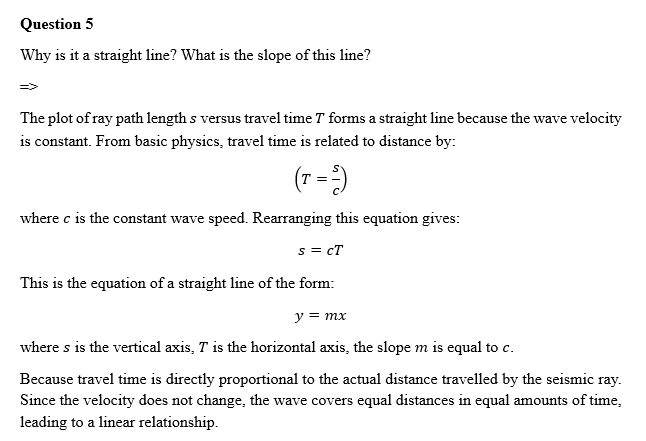

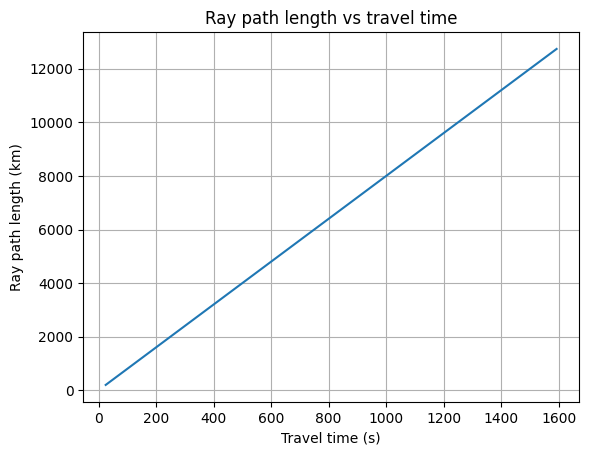

In [5]:
#Q5
# convert Delta to radian
Delta_rad = np.array(Delta_vals)

# calc ray path length
s = 2 * R * np.sin(Delta_rad / 2)

plt.figure()
plt.plot(T_vals, s)
plt.xlabel('Travel time (s)')
plt.ylabel('Ray path length (km)')
plt.title('Ray path length vs travel time')
plt.grid()
plt.show()

### Primary and secondary waves
So far, we did not discuss the waves represented here by rays. In the Earth, we generally have two kinds of waves that travel through the volume: P- and S-waves. Why are they called P- and S-wave? Hint: the equations for the P- and S-wave speeds hold the key to answering this question. Quote them in your report and discuss the three parameters in these definitions (assuming an isotropic medium).

In isotropic media, The primary wave or P-wave speed is $$v_{P}=\sqrt{\frac{K+\frac{4}{3}\mu}{\rho}},$$
where $K$ is the bulk modulus, $\mu$ the shear modulus, and $\rho$ is the density. The S-wave speed is $$v_{S}=\sqrt{\frac{\mu}{\rho}}.$$ Note that $v_p< v_s$. Always.

Not only are P-waves faster than S-waves, they also differ in terms of polarization. S-waves have transverse polarization, just like electromagnetic waves: particles excited by the S-wave are moving perpendicular to the direction of propagation. P-waves, on the other hand, have a longitudinal polarization: particles are moved by the P-wave *in* the direction of propagation.

## The Primary Reference Earth Model (PREM)

In the Earth, the seismic wave speed is far from constant. For example, there is a sudden drop in wave speed (due to a phase change) from the outer to the inner core. More realistic P- and S-wave speeds as a function of the depth, based on seismic observations, are captured in the [Preliminary Reference Earth Model (PREM)](https://en.wikipedia.org/wiki/Preliminary_reference_Earth_model). The code cell below prints the columns of this model for the P-wave and the S-wave:

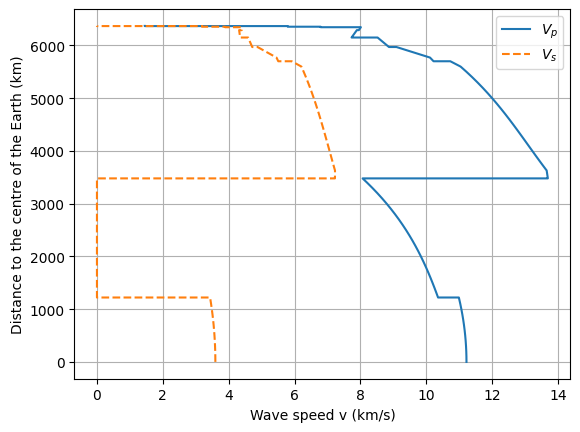

In [6]:
# example
url = "http://ds.iris.edu/files/products/emc/data/PREM/PREM_ANISOTROPIC.csv"

df = pd.read_csv(url, usecols = [0,2,3], names = ['radius', 'vP','vS'], header = None)
vp = np.array(df['vP'])/1000 # in km/s
vs = np.array(df['vS'])/1000 # in km/s
r = np.array(df['radius'])/1000 # radius in km

plt.plot(vp, r, label = '$V_p$')
plt.plot(vs, r, '--', label = '$V_s$')

plt.ylabel('Distance to the centre of the Earth (km)')
plt.xlabel('Wave speed v (km/s)')

#plt.gca().invert_yaxis()
plt.grid()
plt.legend()
plt.show()

### The main features of a radially symmetric Earth
You can divide the PREM model in four regions. 

#### Question 6
Discuss what you see in terms of these regions and relate these observations to what you know about the internal structure of the Earth from you courses in Earthscience from highschool or stage 1 at university.

#### Question 7
The PREM model you loaded in the pandas dataframe `df` has more columns than just $v_P$ and $v_S$.
Plot the column with density of the Earth as a function of $r$. Discuss what you see, and compare this to $v_P$ and $v_S$. Now you know the equations for the wavespeeds, what does this tell you about the parameters involved?

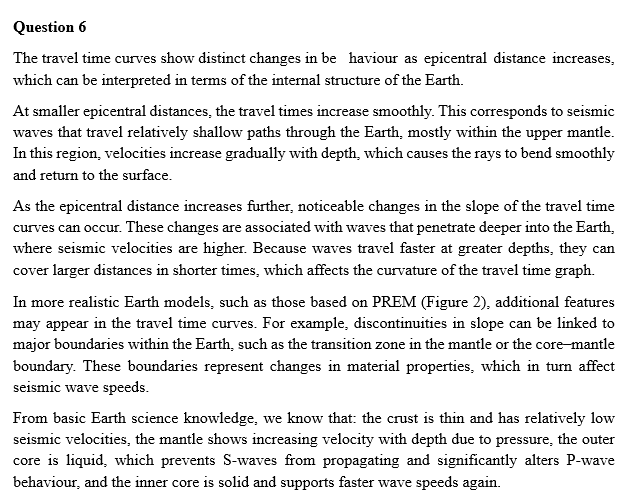
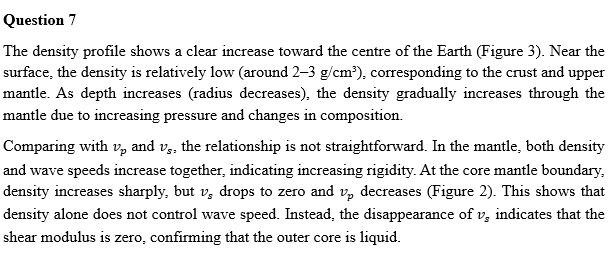

In [7]:
# Q7
url = "http://ds.iris.edu/files/products/emc/data/PREM/PREM_ANISOTROPIC.csv"

df_q7 = pd.read_csv(url, names = ["radius", "density", "Vp", "Vs", "Q_kappa", "Q_mu", "Vph", "Vsh", "eta"], header = None)

"""
radius[unit="m"], density[unit="kg/m^3"], Vpv[unit="m/s"],
Vsv[unit="m/s"], Q-kappa[unit=""], Q-mu[unit=""],
Vph[unit="m/s"],Vsh[unit="m/s"],eta[unit=""]
"""
df_q7.head()

,radius,density,Vp,Vs,Q_kappa,Q_mu,Vph,Vsh,eta
0,0.0,13088.48,11218.18,3594.69,1328.0,85.0,11218.18,3594.69,1.0
1,100000.0,13086.30,11216.62,3593.62,1328.0,85.0,11216.62,3593.62,1.0
2,200000.0,13079.77,11211.97,3590.40,1328.0,85.0,11211.97,3590.40,1.0
3,300000.0,13068.88,11204.21,3585.03,1328.0,85.0,11204.21,3585.03,1.0
4,400000.0,13053.64,11193.34,3577.51,1328.0,85.0,11193.34,3577.51,1.0


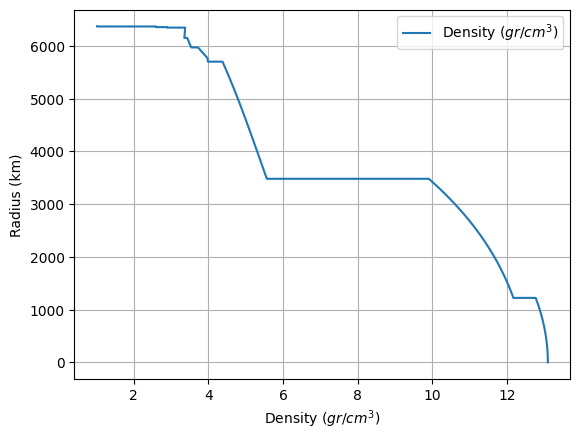

In [8]:
# Q7
plt.plot(df_q7["density"]/1000, df_q7['radius']/1000, label = 'Density ($gr/cm^3$)')
plt.xlabel("Density ($gr/cm^3$)")
plt.ylabel("Radius (km)")
plt.legend()
plt.grid()
plt.show()

### Travel times of seismic rays in the PREM model
Let's estimate the P-wave travel time as a function of epicentral distance based on the PREM $v_P(r)$ and the integrals presented at the start of this notebook. But first, we must interpolate the PREM-supplied $v_P(r)$ to get a regularly spaced 1D array.

#### Question 8
Use the `scipy.interpolate.interp1d` function to create an array of velocities at 400 equally spaced depths in the Earth. The documentation online has examples on how to do interpolation with this function. Plot the interpolated line with the original `r` and `vp` values from above, and include a legend. 

Important: call the new 400 element array with depths `newx` and the new 400-element array with compressional wave speeds for each of these depths `newy`.


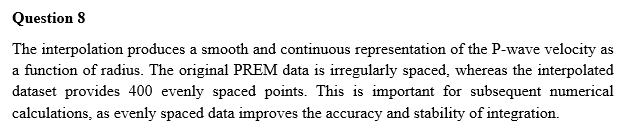

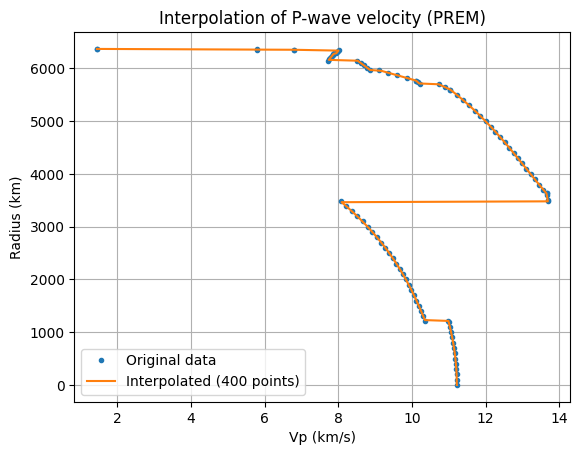

In [9]:
r = df['radius'] / 1000
vp = df['vP'] / 1000

f = interp1d(r, vp, kind = 'linear')

newx = np.linspace(r.min(), r.max(), 400)
newy = f(newx)

plt.figure()
plt.plot(vp, r, 'o', markersize = 3, label = 'Original data')
plt.plot(newy, newx, '-', label = 'Interpolated (400 points)')
plt.ylabel('Radius (km)')
plt.xlabel('Vp (km/s)')
plt.title('Interpolation of P-wave velocity (PREM)')
plt.legend()
plt.grid()
plt.show()

### Integration by Riemann summation
We'll evaluate the integrals by taking [Riemann sums](https://en.wikipedia.org/wiki/Riemann_sum) of the PREM velocity model for the (regular) $v_P(r)$.

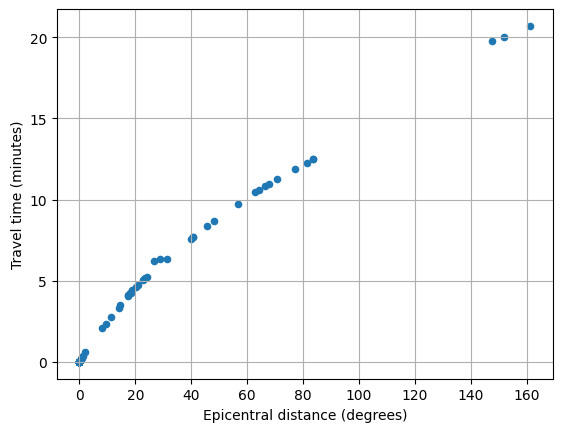

In [10]:
# The velocity model starts at R=0, the centre of the Earth. But our integration starts at the surface and goes to the 
# turning point of the ray. 
# So for our summation to work, we flip the order of the model, so that the first elements of vp and r 
# are at the surface of the Earth:
r= np.flip(newx)
vp = np.flip(newy)

dr = r[0]-r[1] # is the constant for Riemann sums
angles = np.linspace(0.05,0.95*np.pi/2,400) # defining a range of take off angles. Numerical instablities near 0 and 90 degrees need to be avoided.
Tp = []
Deltap = []

for angle in angles:
    p = r[0]*np.sin(angle)/vp[0] # constant ray parameter for each take-off angle
    T = 0
    Delta = 0
    for i in range(1,len(r)):
        if (p*vp[i])< r[i]: # consider the ray from the surface until it turns
            denom = np.sqrt(r[i]**2- (p*vp[i])**2)
            T = T + 2*dr*r[i]/vp[i]/denom
            Delta = Delta + 2*dr*p*vp[i]/r[i]/denom
        else:
            break
    Tp.append(T)
    Deltap.append(Delta)

plt.figure()
plt.scatter(180*np.array(Deltap)/np.pi,np.array(Tp)/60, s=20)
plt.xlabel('Epicentral distance (degrees)')
plt.ylabel('Travel time (minutes)')
plt.grid()
plt.show()

These travel times are quite realistic, but as always: the devil is in the details. Our interpolation has smoothed out some important detail in the velocity model that is responsible for the (correct) P-wave [shadow zone](https://en.wikipedia.org/wiki/Shadow_zone), for example. More sophisticated schemes to estimate travel times for seismic arrivals are explored in the second part of this lab, where we use readily written code based on the (delay-time $\tau$, ray parameter $p$)-domain, originally proposed by Buland and Chapman (1983), coded up in the [Taup toolkit](https://www.seis.sc.edu/taup/), and then wrapped in [ObsPy](https://github.com/obspy/obspy/wiki).

# **Tracing your own seismic ray paths through the Earth**

The software we use for ray tracing in the Earth is called [“TauP”](https://pubs.geoscienceworld.org/ssa/srl/article/70/2/154/142385/the-taup-toolkit-flexible-seismic-travel-time-and). Information about the package, including the manual can be downloaded [here](http://www.seis.sc.edu/TauP/). This code should run in the notebook on Colab, but you are welcome to run the code locally on a lab computer or laptop. You could run TauP standalone, but [obspy](https://docs.obspy.org/) provides a Python class called
Taup, which comes with a function [plot_ray_paths](https://docs.obspy.org/packages/autogen/obspy.taup.tau.plot_ray_paths.html#obspy.taup.tau.plot_ray_paths). This function can be used like this:

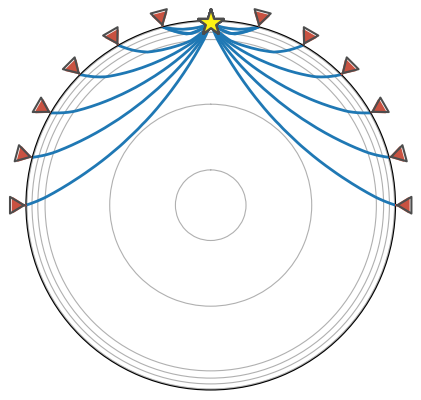

<PolarAxes: >

In [11]:
from obspy.taup.tau import plot_ray_paths
plot_ray_paths(source_depth = 100, phase_list = ['P'], npoints = 25)

#### Question 9
Read the documentation for the `plot_rays` function and plot S- and P-wave arrivals from 0 to 360 degrees. Why are there gaps (shadows) in the arrivals?

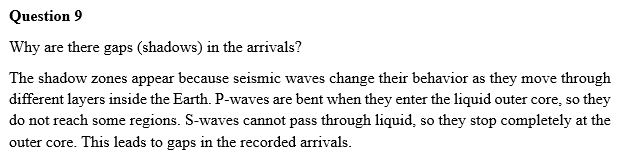

There were rays for all but the following epicentral distances:
 [np.float64(0.0), np.float64(105.0), np.float64(120.0), np.float64(135.0), np.float64(150.0), np.float64(165.0), np.float64(180.0), np.float64(195.0), np.float64(210.0), np.float64(225.0), np.float64(240.0), np.float64(255.0), np.float64(360.0)]


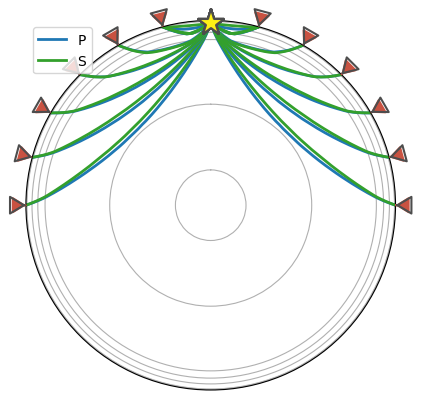

<PolarAxes: >

In [12]:
plot_ray_paths(source_depth = 100, npoints = 25, legend = True, 
               phase_list = ['P', 'S'], verbose = True, 
               label_arrivals = True, min_degrees = 0, max_degrees = 360)

Besides your plain P- and S-wave phases, there are a host of other — more complicated — seismic ray paths from earthquake to receiver. [This link](http://www.iris.edu/data/vocab.htm) describes the naming conventions.

#### Question 10
What is a PKP ray?
Plot the PKP rays and P rays from 0–360 degrees. If we consider PKP a direct compressional arrival, what is the range of the P-wave shadow zone?

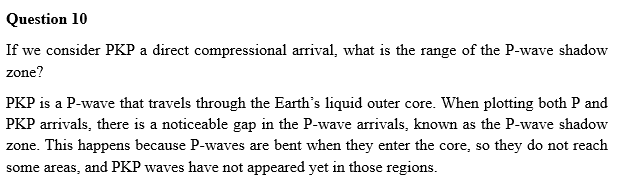

There were rays for all but the following epicentral distances:
 [np.float64(0.0), np.float64(120.0), np.float64(240.0), np.float64(360.0)]


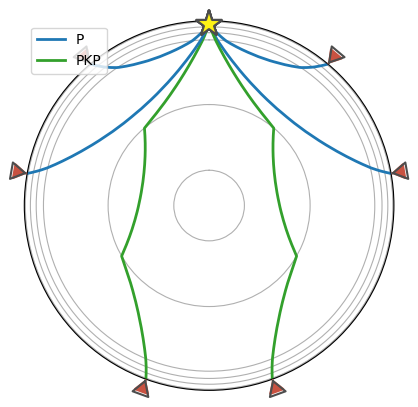

<PolarAxes: >

In [13]:
plot_ray_paths(
    source_depth = 100,
    phase_list = ['P', 'PKP'],
    legend = True,
    verbose = True,
    label_arrivals = True,
    min_degrees = 0,
    max_degrees = 360
)

#### Question 11

Illustrate with a figure and explain in words why P-waves at smaller epicentral distances (0–35 degrees) appear to cross. To zoom in on the ray paths at smaller epicentral distance, use the option to plot ray paths in a Cartesian coordinate system. *Confirm the same occurs for S-waves*.

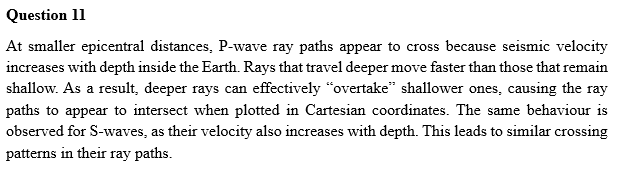

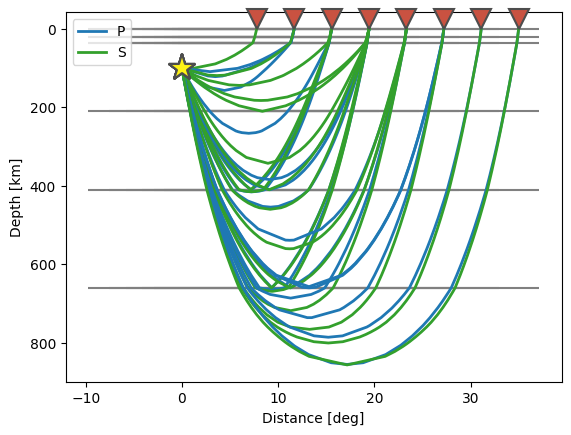

<Axes: xlabel='Distance [deg]', ylabel='Depth [km]'>

In [14]:
plot_ray_paths(
    source_depth = 100,
    phase_list = ["P", "S"],
    plot_type = "cartesian",
    legend = True,
    label_arrivals = False,
    min_degrees = 0,
    max_degrees = 35
)
#plt.grid()

# **The travel times of seismic rays**

The previous tasks involved mainly the spatial distribution of seismic ray paths in the earth. One of the simplest examples of using obspy is to create a travel time plot of different seismic phases. For example, if you execute the following three lines of code, the direct S-wave arrival time as a function of epicentral distance appears:

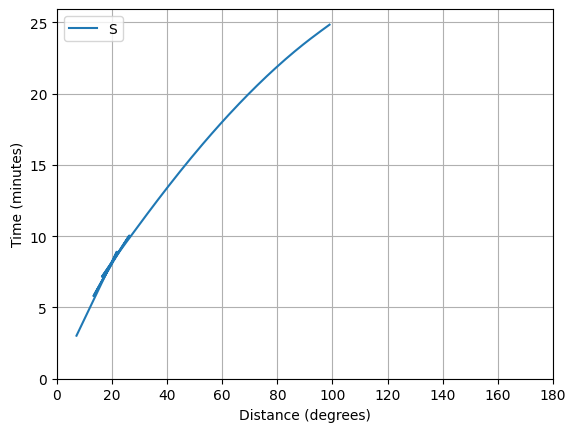

<Axes: xlabel='Distance (degrees)', ylabel='Time (minutes)'>

In [15]:
plot_travel_times(source_depth = 100, phase_list = ["S"])

#### Question 12

Make one figure that contains the travel-time curves for P, S, SS, and PP arrivals at 100 points between 0 and 90 degrees epicentral distance, for an earthquake at 100 km depth. What are the definitions of these four wave types?

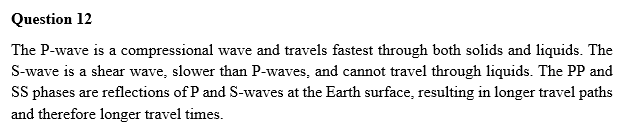

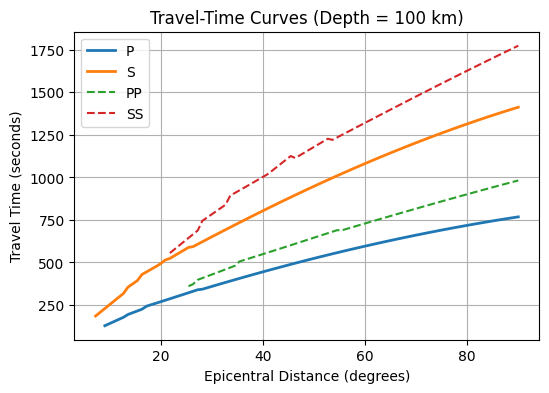

In [16]:
model = TauPyModel(model = "iasp91")

distances = np.linspace(0, 90, 100)

p_times = []
s_times = []
pp_times = []
ss_times = []

for d in distances:
    arrivals = model.get_travel_times(
        source_depth_in_km = 100,
        distance_in_degree=d,
        phase_list = ["P", "S", "PP", "SS"]
    )
    
    p, s, pp, ss = np.nan, np.nan, np.nan, np.nan
    
    for a in arrivals:
        if a.name == "P":
            p = a.time
        elif a.name == "S":
            s = a.time
        elif a.name == "PP":
            pp = a.time
        elif a.name == "SS":
            ss = a.time
    
    p_times.append(p)
    s_times.append(s)
    pp_times.append(pp)
    ss_times.append(ss)


plt.figure(figsize=(6,4))

plt.plot(distances, p_times, label = "P", linewidth=2)
plt.plot(distances, s_times, label = "S", linewidth=2)
plt.plot(distances, pp_times, label = "PP", linestyle='--')
plt.plot(distances, ss_times, label = "SS", linestyle='--')

plt.xlabel("Epicentral Distance (degrees)")
plt.ylabel("Travel Time (seconds)")
plt.title("Travel-Time Curves (Depth = 100 km)")

plt.legend()
plt.grid()
plt.show()

### Epicentre estimation from seismograms

The previous analyses were based on models where the elastic properties only vary in the radial direction; in other words, the Earth we considered has a *spherical symmetry*. In the remainder of this lab, we will see that this assumption is good enough to estimate the epicentre of a real earthquake.

#### Question 13

The following code downloads seismic data for station SNZO from IRIS with the recordings of an Earthquake:

<Figure size 640x480 with 0 Axes>

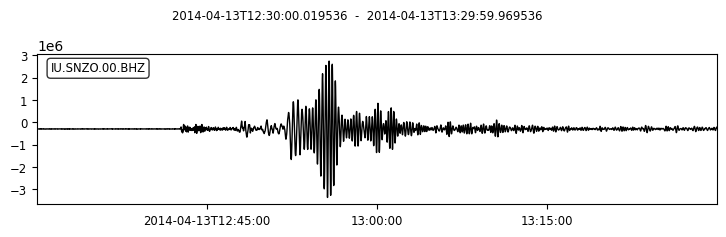

In [17]:
client = Client("IRIS") # IRIS is the host of the data
t1 = UTCDateTime('2014-04-13T12:30:00.00') # start time 
t2 = t1 + 3600 # end time

########################################################### SNZO (South Karori, New Zealand)
st_snzo = client.get_waveforms("IU", "SNZO", "00", "BHZ", t1, t2)

########################################################### FUNA (Funafuti, Tuvalu)
st_funa = client.get_waveforms("IU", "FUNA", "00", "LHZ", t1, t2)

########################################################### DAV (Davao, Philippines)
st_dav = client.get_waveforms("IU", "DAV", "00", "LHZ", t1, t2)

plt.figure()
st_snzo.plot(); 
plt.show()

Zoom in on the part of the graph that you think contains the important body wave arrivals. If you use Colab, you cannot zoom in a figure panel, but you should use the [trim function](https://docs.obspy.org/packages/autogen/obspy.core.stream.Stream.trim.html). 

Identify the arrival time of the P, S, SS, and PP arrival. Your earlier work determines the order of these arrivals. 

By the way, the largest amplitudes in the seismogram are due to surface waves. Plot the arrivals on the graph by making use of this example code:

### Phase picking process

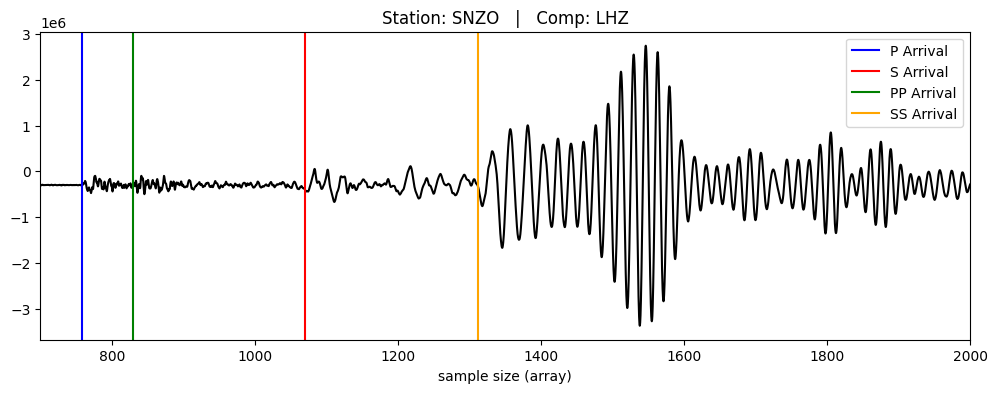

In [18]:
stt_snzo = st_snzo.copy();
plt.figure(figsize = (12, 4))
plt.plot(stt_snzo[0].times(), stt_snzo[0].data, c = 'k');

P_snzo = 759
S_snzo = 1070

PP_snzo = 830
SS_snzo = 1312

plt.axvline(x = P_snzo, label = 'P Arrival', color = 'blue')
plt.axvline(x = S_snzo, label = 'S Arrival', color = 'red')

plt.axvline(x = PP_snzo, label = 'PP Arrival', color = 'green')
plt.axvline(x = SS_snzo, label = 'SS Arrival', color = 'orange')

dist_deg_snzo = (S_snzo-P_snzo)/8

plt.title("Station: SNZO   |   Comp: LHZ")
plt.xlim(700,2000)
plt.xlabel("sample size (array)")
plt.legend()
plt.show()

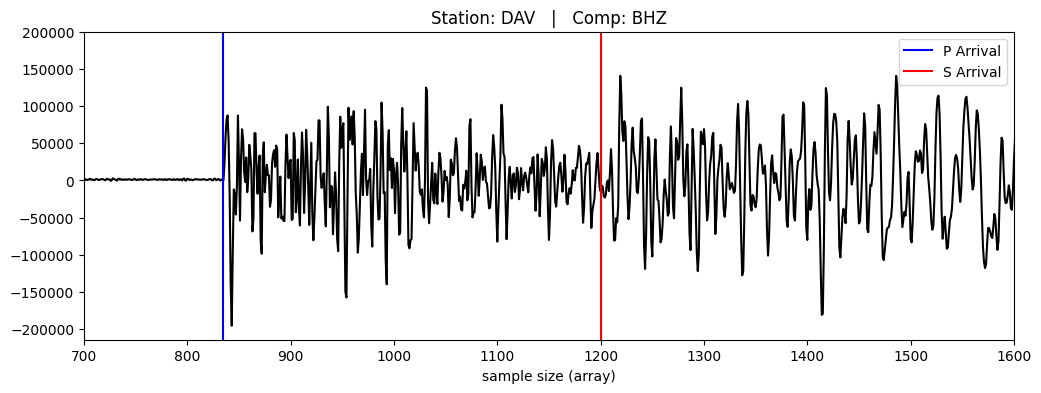

In [19]:
stt_dav = st_dav.copy();
plt.figure(figsize = (12, 4))
plt.plot(stt_dav[0].times(), stt_dav[0].data, c = 'k');

P_dav = 835
S_dav = 1200

plt.axvline(x = P_dav, label = 'P Arrival', color = 'blue')
plt.axvline(x = S_dav, label = 'S Arrival', color = 'red')

dist_deg_dav = (S_dav-P_dav)/8

plt.title("Station: DAV   |   Comp: BHZ")
plt.xlim(700, 1600)
plt.xlabel("sample size (array)")
plt.legend()
plt.show()

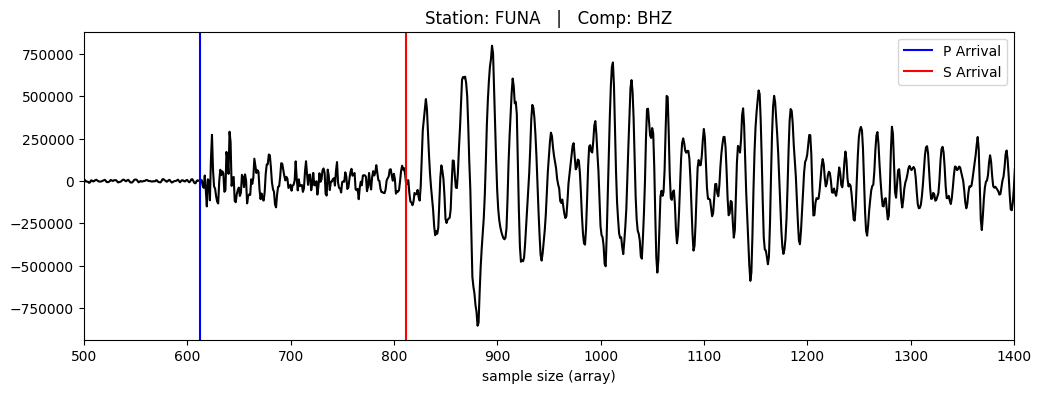

In [20]:
stt_funa = st_funa.copy()
plt.figure(figsize = (12, 4))
plt.plot(stt_funa[0].times(), stt_funa[0].data, c = 'k');

P_funa = 612
S_funa = 812

plt.axvline(x = P_funa, label = 'P Arrival', color = 'blue')
plt.axvline(x = S_funa, label = 'S Arrival', color = 'red')

dist_deg_funa = (S_funa-P_funa)/8

plt.title("Station: FUNA   |   Comp: BHZ")
plt.xlim(500, 1400)
plt.xlabel("sample size (array)")
plt.legend()
plt.show()

#### Question 14
Calculate the delay times between the arrivals of P, S, PP, and SS waves. Use these delay times and your graph of predicted arrival times from before to estimate the epicentral distance of this earthquake.

In [21]:
# Delay times
t_ps = S_snzo - P_snzo     # S-P
t_pp = PP_snzo - P_snzo      # PP-p
t_ss = SS_snzo - P_snzo    # SS-P
distance_deg_snzo = t_ps/8
distance_deg_snzo # degrees

38.875

#### Question 15

Plot a circle with a radius equal to the epicentral distance from SNZO on a world map using this example code:

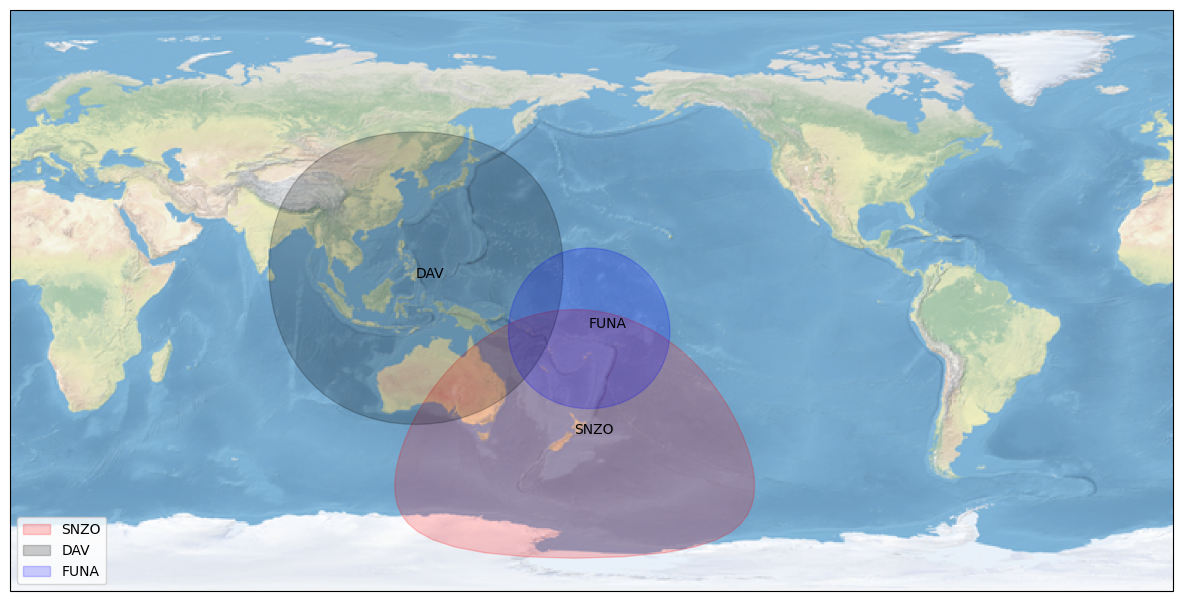

In [22]:
# define a map, and its projection:
plt.figure(figsize=(15,15))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.stock_img()

# Plot a circle on the map, centered on "station" with a lat lon. The radius is "radius"
station = 'SNZO'
lon = 174.704 
lat = -41.309

station2 = 'DAV'
lon2 = 125.5791
lat2 = 	7.0697

station3 = 'FUNA'
lon3 = 179.1966
lat3 = -8.5259

ax.tissot(rad_km = dist_deg_snzo*110, lons = lon, lats = lat, alpha = 0.2, color = 'r')
ax.tissot(rad_km = dist_deg_dav*110, lons = lon2, lats = lat2, alpha = 0.2, color = 'k')
ax.tissot(rad_km = dist_deg_funa*110, lons = lon3, lats = lat3, alpha = 0.2, color = 'b')

ax.text(lon, lat, station, transform = ccrs.Geodetic())
ax.text(lon2, lat2, station2, transform = ccrs.Geodetic())
ax.text(lon3, lat3, station3, transform = ccrs.Geodetic())

legend_elements = [
    mpatches.Patch(color = 'r', alpha = 0.2, label = 'SNZO'),
    mpatches.Patch(color = 'k', alpha = 0.2, label = 'DAV'),
    mpatches.Patch(color = 'b', alpha = 0.2, label = 'FUNA'),
]

ax.legend(handles = legend_elements, loc = 'lower left')
plt.show()

#### Question 16
With the code used to download data for station SNZO, obtain seismograms from two other stations. Then repeat steps 12-15 two draw two more circles on your map. [This page](https://www.fdsn.org/networks/detail/IU/) contains a map with all the different stations you could use and their corresponding station codes.
#### Question 17
Estimate the origin time $T_0$ and epicentre to find the most likely candidate for this earthquake. in an earthquake catalogue. Add the epicentre of this earthquake to your map to see how close your estimate is to that of the professionals. You may have to make a new map that zooms in around the epicentre to judge and discuss your results.  

In [23]:
# Q17
P_snzo = 759
P_dav  = 835
P_funa = 612

depth = 100  # km

arr_snzo = model.get_travel_times(depth, dist_deg_snzo, phase_list = ["P"])
arr_dav  = model.get_travel_times(depth, dist_deg_dav,  phase_list = ["P"])
arr_funa = model.get_travel_times(depth, dist_deg_funa, phase_list =["P"])

T0_snzo = P_snzo - arr_snzo[0].time
T0_dav  = P_dav  - arr_dav[0].time
T0_funa = P_funa - arr_funa[0].time

t1 = UTCDateTime("2014-04-13T12:30:00")

print("T0 FUNA:", t1+T0_funa)
print("T0 SNZO:", t1+T0_snzo)
print("T0 DAV :", t1+T0_dav)

T0_mean = (T0_snzo + T0_dav + T0_funa) / 3

print("\nMean T0 (s):", T0_mean)

T0_time = t1 - T0_mean
print("Estimated Origin Time:", T0_time)

T0 FUNA: 2014-04-13T12:34:57.607893Z
T0 SNZO: 2014-04-13T12:35:23.598698Z
T0 DAV : 2014-04-13T12:35:44.853892Z

Mean T0 (s): 322.020161028069
Estimated Origin Time: 2014-04-13T12:24:37.979839Z


In [24]:
# Earthquake event data retrieved from the IRIS database to compared vs calculated epicenter.

client = Client("IRIS")

t1 = UTCDateTime("2014-04-13T12:30:00")
t2 = t1 + 180

catalog = client.get_events(starttime=t1, endtime=t2)
data = []
for event in catalog:
    origin = event.origins[0]
    magnitude = event.magnitudes[0] if event.magnitudes else None
    
    data.append({"time": origin.time, "latitude": origin.latitude, "longitude": origin.longitude,
        "depth_km": origin.depth / 1000, "magnitude": magnitude.mag if magnitude else None})

df_events = pd.DataFrame(data)
df_events # database events

,time,latitude,longitude,depth_km,magnitude
0,2014-04-13T12:32:04.950000Z,-11.2579,162.2991,10.0,4.4


In [25]:
# Epicenter calculation by 3 circle / triangulations method
r1 = dist_deg_snzo
r2 = dist_deg_dav
r3 = dist_deg_funa

x1, y1 = lon,  lat
x2, y2 = lon2, lat2
x3, y3 = lon3, lat3

A = 2*(x2 - x1)
B = 2*(y2 - y1)
C = r1**2 - r2**2 + x2**2 - x1**2 + y2**2 - y1**2

D = 2*(x3 - x1)
E = 2*(y3 - y1)
F = r1**2 - r3**2 + x3**2 - x1**2 + y3**2 - y1**2

# solve linear system
denom = A*E - B*D

lon_e = (C*E - B*F) / denom
lat_e = (A*F - C*D) / denom

print("Calc Latitude:", lat_e)
print("Calc Longitude:", lon_e)

Calc Latitude: -9.544378243748557
Calc Longitude: 163.40710982229297


In [26]:
# residual between IRIS vs 3 Circle method
print("Latitude res (degrees):", abs(lat_e-df_events['latitude'][0]))
print("Longitude res (degrees):", abs(lon_e-df_events['longitude'][0]))

Latitude res (degrees): 1.713521756251442
Longitude res (degrees): 1.1080098222929564


In [27]:
# residual origin time
print("origin time residual (minute):", abs(UTCDateTime(df_events['time'][0])-T0_time)/60)

origin time residual (minute): 7.449502683333334


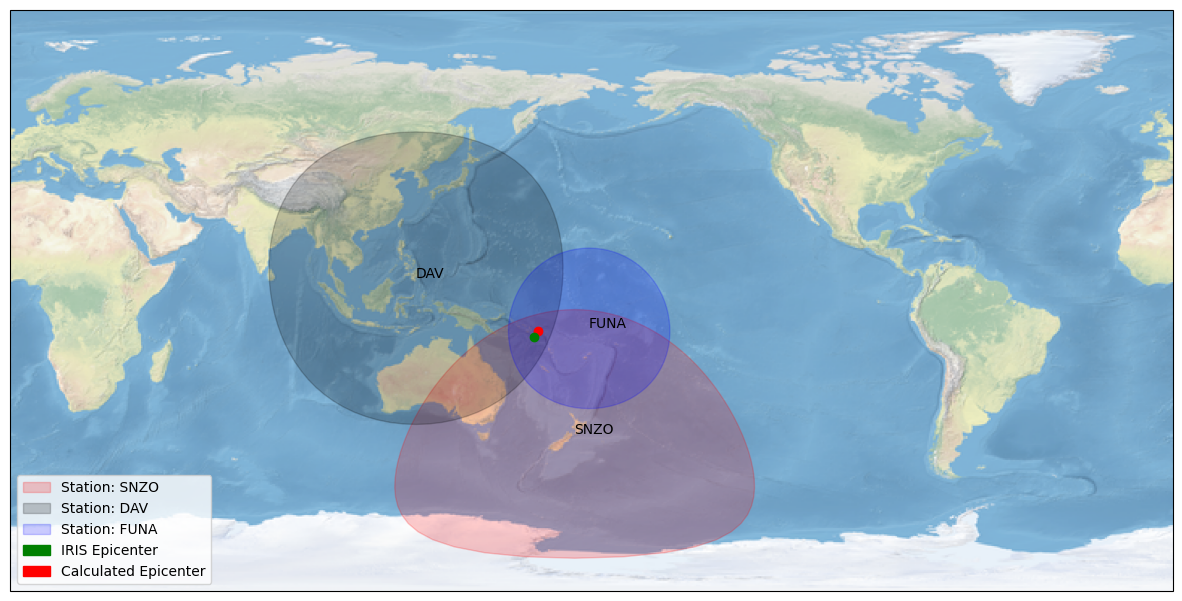

In [28]:
# define a map, and its projection:
plt.figure(figsize=(15,15))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.stock_img()

station = 'SNZO'
lon = 174.704 
lat = -41.309

a = df_events['longitude'][0] # IRIS database epicenter coordinate
b = df_events['latitude'][0]

station2 = 'DAV'
lon2 = 125.5791
lat2 = 	7.0697

station3 = 'FUNA'
lon3 = 179.1966
lat3 = -8.5259

ax.tissot(rad_km = dist_deg_snzo*110, lons = lon, lats = lat, alpha = 0.2, color = 'r')
ax.tissot(rad_km = dist_deg_dav*110, lons = lon2, lats = lat2, alpha = 0.2, color = 'k')
ax.tissot(rad_km = dist_deg_funa*110, lons = lon3, lats = lat3, alpha = 0.2, color = 'b')
ax.plot(lon_e, lat_e, 'ro', label = 'Calculated', transform = ccrs.Geodetic())
ax.plot(a, b, 'go', label = 'IRIS', transform = ccrs.Geodetic())
#ax.tissot(rad_km = 150, lons = a, lats = b, alpha = 1, facecolor = 'green', edgecolor = 'green',linewidth = 3)

ax.text(lon, lat, station, transform = ccrs.Geodetic())
ax.text(lon2, lat2, station2, transform = ccrs.Geodetic())
ax.text(lon3, lat3, station3, transform = ccrs.Geodetic())
#ax.text(a, b, "Epicenter", transform = ccrs.Geodetic(), fontsize=8, color='white')

# legend
legend_elements = [mpatches.Patch(color = 'r', alpha = 0.2, label = 'Station: SNZO'),mpatches.Patch(color = 'k', alpha = 0.2, label = 'Station: DAV'),
    mpatches.Patch(color = 'b', alpha = 0.2, label = 'Station: FUNA'), mpatches.Patch(color = 'green', label = 'IRIS Epicenter'),
                   mpatches.Patch(color = 'red', label = 'Calculated Epicenter')]

ax.legend(handles = legend_elements, loc = 'lower left')
plt.show()

## Final comparison plot

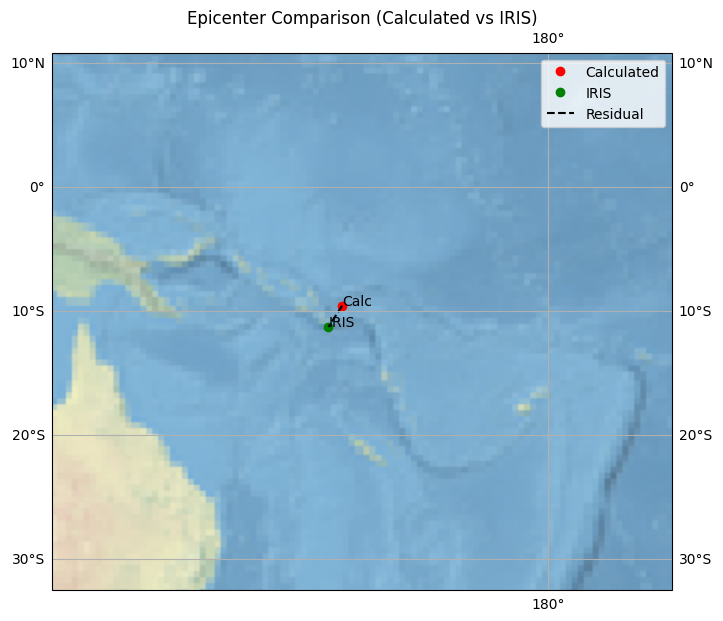

In [29]:
### Comparison plot
calc_lon = lon_e
calc_lat = lat_e

obs_lon = df_events['longitude'][0]
obs_lat = df_events['latitude'][0]


plt.figure(figsize=(8,8))
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=180))
ax.stock_img()

ax.plot(calc_lon, calc_lat, 'ro', label = 'Calculated', transform = ccrs.Geodetic())
ax.plot(obs_lon, obs_lat, 'go', label = 'IRIS', transform = ccrs.Geodetic())

ax.text(calc_lon, calc_lat, 'Calc', transform = ccrs.Geodetic())
ax.text(obs_lon, obs_lat, 'IRIS', transform = ccrs.Geodetic())

ax.plot([calc_lon, obs_lon], [calc_lat, obs_lat], 'k--', transform = ccrs.Geodetic(), label = 'Residual')


ax.set_extent([140, 190, -30, 10]) 
ax.gridlines(draw_labels = True)
ax.legend()
plt.title("Epicenter Comparison (Calculated vs IRIS)")
plt.show()

#### Discussion

The calculated epicenter shows a noticeable difference compared to the IRIS database results, with an offset residual of approximately 1.7 degrees in latitude and 1.1 degrees in longitude. This discrepancy can be attributed to several factors. One possible reason is the difference in picking the onset of P and S waves. Even small variations, on the order of milliseconds, can lead to significant changes in the estimated epicenter location.

Another important factor is the velocity model used in the calculation. In this assignment, a constant velocity of Vp=8km/s was assumed. In contrast, professional analyses typically use more advanced velocity models that account for variations in subsurface properties, where seismic wave velocities change with depth. These simplifications can contribute to the differences observed between the calculated and reference epicenters.

The method used to determine the earthquake location also plays a significant role (triangulation, grid search, random search, geiger, etc). In this study, a simple triangulation (three-circle) method was applied. However, professional analyses often use more advanced techniques, such as inversion based approaches or even double-difference relocation methods, which can significantly improve accuracy by minimizing relative location errors between events.